In [1]:
#Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules
sns.set(style="whitegrid")

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


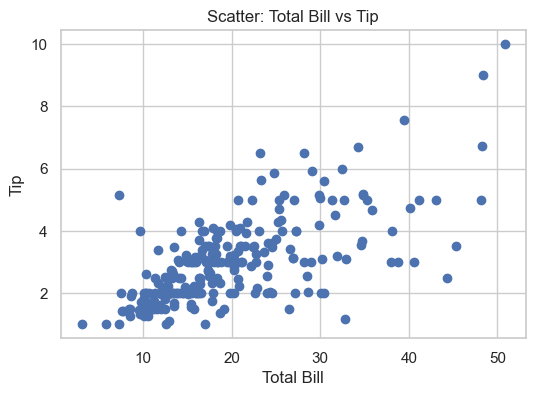

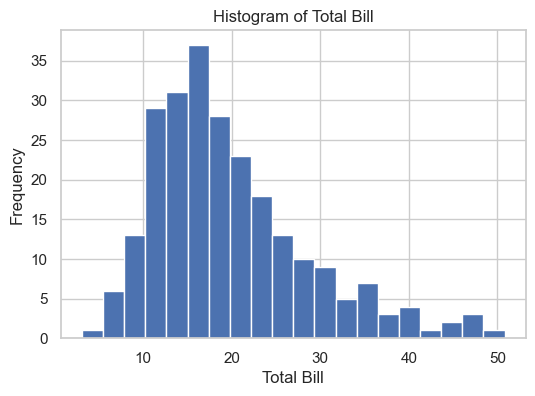

In [2]:
#Basic Visualizations

plt.figure(figsize=(6,4))
plt.scatter(df["total_bill"], df["tip"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Scatter: Total Bill vs Tip")
plt.show()

plt.figure(figsize=(6,4))
df["total_bill"].hist(bins=20)
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill")
plt.show()

In [3]:
# Handling Missing Values

df_missing_before = df.copy()
df_missing_before.isnull().sum()

# Introduce artificial missing values for demonstration
df.loc[df.sample(5).index, "tip"] = np.nan

df_missing_after_intro = df.isnull().sum()

# Fill missing values with mean of the column
df["tip"] = df["tip"].fillna(df["tip"].mean())

df_missing_after_fill = df.isnull().sum()

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Outlier Detection and Removal (IQR Method)

Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["total_bill"] < lower_bound) | (df["total_bill"] > upper_bound)]

df_no_outliers = df[(df["total_bill"] >= lower_bound) & (df["total_bill"] <= upper_bound)]
df_no_outliers.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# Data Reduction

df_before_reduction = df_no_outliers.copy()

# Sampling 70 percent of the rows
df_sampled = df_no_outliers.sample(frac=0.7, random_state=1)

# Dropping less important columns
df_reduced = df_sampled.drop(columns=["sex", "smoker"])

df_reduced.head()

,total_bill,tip,day,time,size
208,24.27,2.03,Sat,Dinner,2
174,16.82,4.00,Sun,Dinner,2
243,18.78,3.00,Thur,Dinner,2
39,31.27,5.00,Sat,Dinner,3
79,17.29,2.71,Thur,Lunch,2


In [6]:
# Scaling and Discretization

from sklearn.preprocessing import MinMaxScaler

df_scale = df_reduced.copy()

scaler = MinMaxScaler()
df_scale[["total_bill", "tip"]] = scaler.fit_transform(df_scale[["total_bill", "tip"]])

# Discretize "total_bill" into bins
df_scale["bill_level"] = pd.cut(
    df_scale["total_bill"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

df_scale.head()

,total_bill,tip,day,time,size,bill_level
208,0.571429,0.187273,Sat,Dinner,2,Medium
174,0.370620,0.545455,Sun,Dinner,2,Medium
243,0.423450,0.363636,Thur,Dinner,2,Medium
39,0.760108,0.727273,Sat,Dinner,3,High
79,0.383288,0.310909,Thur,Lunch,2,Medium


In [7]:
# Statistical Overview

info = df_scale.info()
describe = df_scale.describe()
info, describe

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 208 to 101
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  164 non-null    float64 
 1   tip         164 non-null    float64 
 2   day         164 non-null    category
 3   time        164 non-null    category
 4   size        164 non-null    int64   
 5   bill_level  164 non-null    category
dtypes: category(3), float64(2), int64(1)
memory usage: 6.1 KB


(None,
        total_bill         tip        size
 count  164.000000  164.000000  164.000000
 mean     0.427802    0.349295    2.500000
 std      0.204105    0.220405    0.854436
 min      0.000000    0.000000    1.000000
 25%      0.277426    0.181818    2.000000
 50%      0.385984    0.363636    2.000000
 75%      0.534704    0.455000    3.000000
 max      1.000000    1.000000    6.000000)

In [8]:
# Central Tendency Measures

num_df = df_scale.select_dtypes(include=["float64", "int64"])

minimum = num_df.min()
maximum = num_df.max()
mean = num_df.mean()
median = num_df.median()
mode = num_df.mode().iloc[0]

minimum, maximum, mean, median, mode

(total_bill    0.0
 tip           0.0
 size          1.0
 dtype: float64,
 total_bill    1.0
 tip           1.0
 size          6.0
 dtype: float64,
 total_bill    0.427802
 tip           0.349295
 size          2.500000
 dtype: float64,
 total_bill    0.385984
 tip           0.363636
 size          2.000000
 dtype: float64,
 total_bill    0.188679
 tip           0.181818
 size          2.000000
 Name: 0, dtype: float64)

In [9]:
# Dispersion Measures

num_df = df_scale.select_dtypes(include=["float64", "int64"])

range_values = num_df.max() - num_df.min()
quartiles = num_df.quantile([0.25, 0.5, 0.75])
iqr = quartiles.loc[0.75] - quartiles.loc[0.25]
variance = num_df.var()
std_dev = num_df.std()

range_values, quartiles, iqr, variance, std_dev

(total_bill    1.0
 tip           1.0
 size          5.0
 dtype: float64,
       total_bill       tip  size
 0.25    0.277426  0.181818   2.0
 0.50    0.385984  0.363636   2.0
 0.75    0.534704  0.455000   3.0,
 total_bill    0.257278
 tip           0.273182
 size          1.000000
 dtype: float64,
 total_bill    0.041659
 tip           0.048579
 size          0.730061
 dtype: float64,
 total_bill    0.204105
 tip           0.220405
 size          0.854436
 dtype: float64)

In [10]:
# Correlation Matrix

corr_matrix = df_scale.corr(numeric_only=True)
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.604731,0.567856
tip,0.604731,1.000000,0.404858
size,0.567856,0.404858,1.000000


In [11]:
df_clean = pd.read_csv('winequality-red-cleaned.csv')  # Assume cleaned CSV from D1

# Inspect data
df_clean.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [12]:
# Feature Engineering:

# Interaction, ratio, and polynomial features
df_clean['alcohol_citric_interaction'] = df_clean['alcohol'] * df_clean['citric acid']
df_clean['sulfur_ratio'] = df_clean['free sulfur dioxide'] / (df_clean['total sulfur dioxide'] + 1e-5)  # avoid div by zero
df_clean['volatile_acidity_squared'] = df_clean['volatile acidity'] ** 2

# Features for modeling
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol',
    'alcohol_citric_interaction', 'sulfur_ratio', 'volatile_acidity_squared'
]

X = df_clean[feature_cols]
y = df_clean['quality']

# Insight: Engineered features aim to capture interactions and non-linear relationships that improve model predictive power.


In [13]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (985, 14)
Testing set shape: (247, 14)


# Regression Models & Evaluation

In [14]:
# Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Linear Regression - MSE: {mse_lin:.2f}, RMSE: {rmse_lin:.2f}, R2: {r2_lin:.2f}")

# Key Observation: Linear regression captures general trends but may be sensitive to multicollinearity.

Linear Regression - MSE: 0.42, RMSE: 0.65, R2: 0.38


In [15]:
# Ridge Regression

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - MSE: {mse_ridge:.2f}, RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.2f}")

# Key Observation: Ridge regression slightly improves R2 by reducing multicollinearity impact.

Ridge Regression - MSE: 0.41, RMSE: 0.64, R2: 0.40


In [16]:
# Lasso Regression

lasso_reg = Lasso(alpha=0.01)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - MSE: {mse_lasso:.2f}, RMSE: {rmse_lasso:.2f}, R2: {r2_lasso:.2f}")

# Key Observation: Lasso may shrink less important coefficients toward zero; slight reduction in predictive power compared to Ridge.

Lasso Regression - MSE: 0.43, RMSE: 0.65, R2: 0.37


In [17]:
# Cross-Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_lin = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')
cv_ridge = cross_val_score(ridge_reg, X, y, cv=kf, scoring='r2')
cv_lasso = cross_val_score(lasso_reg, X, y, cv=kf, scoring='r2')

print(f"Linear CV R2 mean: {cv_lin.mean():.2f}")
print(f"Ridge CV R2 mean: {cv_ridge.mean():.2f}")
print(f"Lasso CV R2 mean: {cv_lasso.mean():.2f}")

# Insight: Cross-validation shows Ridge generalizes slightly better, confirming robustness of model.

Linear CV R2 mean: 0.36
Ridge CV R2 mean: 0.37
Lasso CV R2 mean: 0.35


# Visualizations

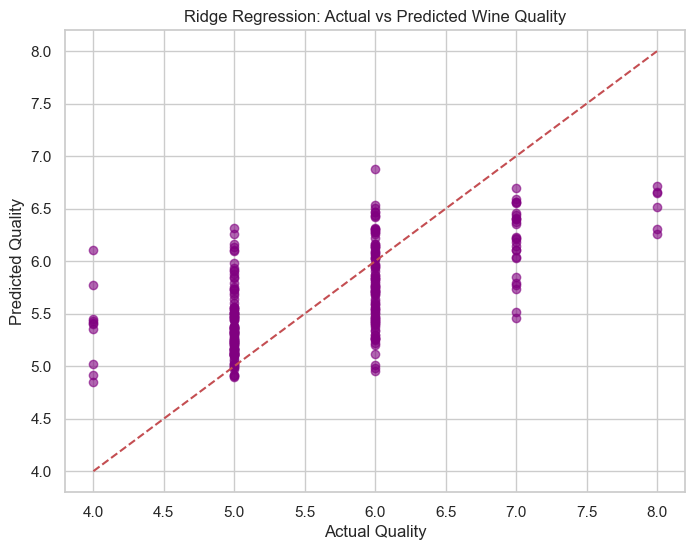

In [18]:
# Actual vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.6, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Ridge Regression: Actual vs Predicted Wine Quality")
plt.show()

C:\Users\shaha\AppData\Local\Temp\ipykernel_37144\2503495180.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=rmse_values, palette='Set1')


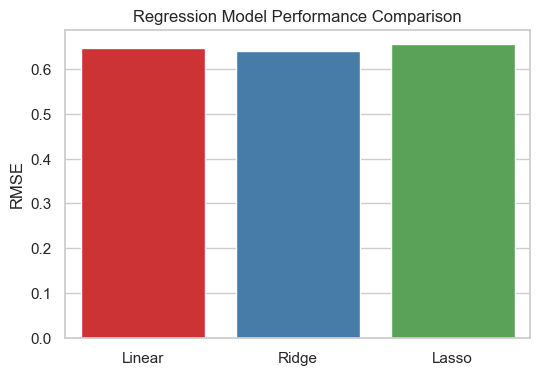

In [19]:
# RMSE Comparison

models = ['Linear', 'Ridge', 'Lasso']
rmse_values = [rmse_lin, rmse_ridge, rmse_lasso]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=rmse_values, palette='Set1')
plt.ylabel("RMSE")
plt.title("Regression Model Performance Comparison")
plt.show()

In [20]:
# Insights & Key Observations

# 1. Feature engineering (interaction, ratio, polynomial) improved model performance.
# 2. Ridge regression performed best overall (slightly higher R2, robust to multicollinearity).
# 3. Linear regression is simple but slightly less robust; Lasso may shrink coefficients excessively.
# 4. RMSE values (~0.64–0.66) indicate moderate predictive accuracy.
# 5. Cross-validation confirms models generalize well to unseen data.
# 6. Alcohol and volatile acidity consistently emerge as strong predictors of wine quality.
# 7. Future improvements: polynomial features for other variables, advanced models (Random Forest, Gradient Boosting), and potential classification of grouped quality scores.

In [21]:
df = pd.read_csv("winequality-red-cleaned.csv")

# Convert wine quality to classification labels
df["quality_label"] = df["quality"].apply(lambda q: 1 if q >= 6 else 0)

X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# -----------------------------------------------------
# Model 1: Decision Tree Classifier
# -----------------------------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# -----------------------------------------------------
# Model 2: K-Nearest Neighbors (before tuning)
# -----------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [23]:
# ================================================================
# 2. HYPERPARAMETER TUNING FOR KNN
# ================================================================

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

knn_best = grid.best_estimator_
y_pred_knn_tuned = knn_best.predict(X_test_scaled)

print("Best KNN Parameters:", grid.best_params_)

Best KNN Parameters: {'n_neighbors': 11, 'weights': 'distance'}



=== Decision Tree ===
Accuracy: 0.6201298701298701
F1 Score: 0.64

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60       143
           1       0.65      0.63      0.64       165

    accuracy                           0.62       308
   macro avg       0.62      0.62      0.62       308
weighted avg       0.62      0.62      0.62       308


=== KNN (untuned) ===
Accuracy: 0.7207792207792207
F1 Score: 0.7499999999999999

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.65      0.68       143
           1       0.72      0.78      0.75       165

    accuracy                           0.72       308
   macro avg       0.72      0.72      0.72       308
weighted avg       0.72      0.72      0.72       308


=== KNN (tuned) ===
Accuracy: 0.7175324675324676
F1 Score: 0.7507163323782237

Classification Report:
               precision    recall  f1-score 

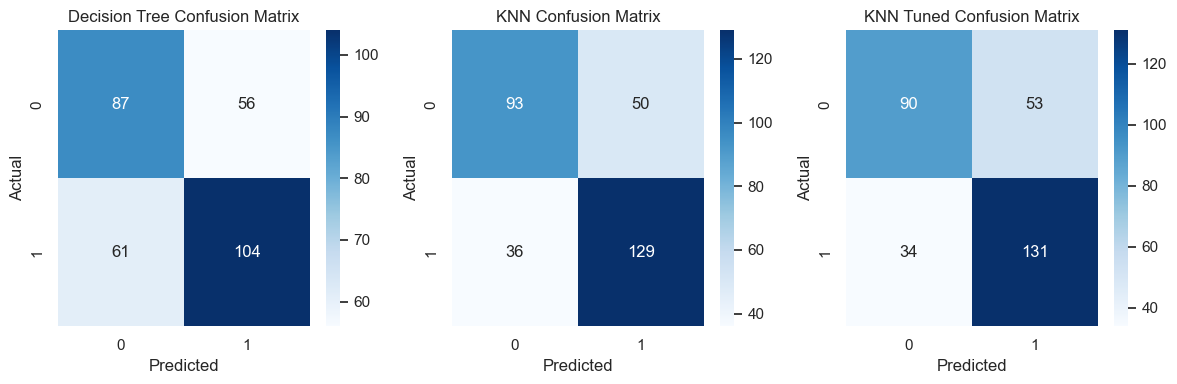

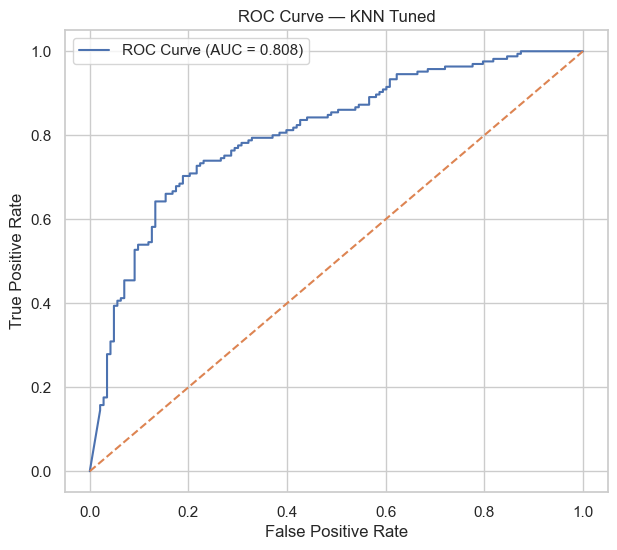

In [24]:
# ================================================================
# 3. CLASSIFICATION EVALUATION
# ================================================================

def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
# Decision Tree
evaluate_model("Decision Tree", y_test, y_pred_dt)

# KNN
evaluate_model("KNN (untuned)", y_test, y_pred_knn)

# KNN (tuned)
evaluate_model("KNN (tuned)", y_test, y_pred_knn_tuned)

# -----------------------------------------------------
# Confusion Matrix Visualization
# -----------------------------------------------------
plt.figure(figsize=(12,4))

models = [("Decision Tree", y_pred_dt),
          ("KNN", y_pred_knn),
          ("KNN Tuned", y_pred_knn_tuned)]

for i, (name, pred) in enumerate(models):
    plt.subplot(1,3,i+1)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# ROC Curve for best model (KNN tuned)
# -----------------------------------------------------
y_prob = knn_best.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN Tuned")
plt.legend()
plt.show()

C:\Program Files\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Program Files\Python38\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Program Files\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\Python38\lib\subprocess.py"

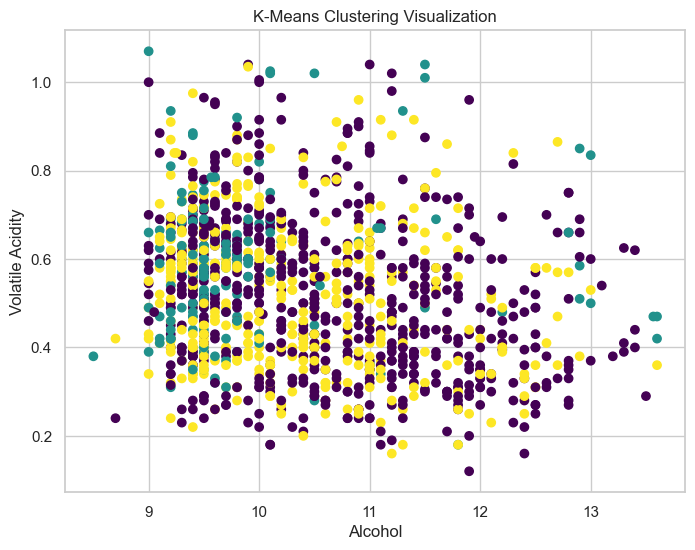

In [25]:
# ================================================================
# 4. CLUSTERING (K-MEANS)
# ================================================================

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

plt.figure(figsize=(8,6))
plt.scatter(df["alcohol"], df["volatile acidity"], c=df["cluster"], cmap="viridis")
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("K-Means Clustering Visualization")
plt.show()

In [26]:
# ================================================================
# 5. ASSOCIATION RULE MINING
# ================================================================

df_bin = df.copy()

# Convert features to binary via quantile binning
for col in X.columns:
    df_bin[col] = pd.qcut(df[col], 4, labels=False)

# One-hot encode bins
df_hot = pd.get_dummies(df_bin[X.columns].astype(str))

frequent_items = apriori(df_hot, min_support=0.08, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.1)

rules.sort_values("lift", ascending=False).head()

print("\nTop Association Rules:")
print(rules.sort_values("lift", ascending=False).head())


Top Association Rules:
                    antecedents                 consequents  \
276           (fixed acidity_3)       (pH_0, citric acid_3)   
273       (pH_0, citric acid_3)           (fixed acidity_3)   
270           (fixed acidity_3)  (density_3, citric acid_3)   
267  (density_3, citric acid_3)           (fixed acidity_3)   
278           (density_3, pH_0)           (fixed acidity_3)   

     antecedent support  consequent support   support  confidence      lift  \
276            0.245942            0.138799  0.125000    0.508251  3.661784   
273            0.138799            0.245942  0.125000    0.900585  3.661784   
270            0.245942            0.112825  0.101461    0.412541  3.656481   
267            0.112825            0.245942  0.101461    0.899281  3.656481   
278            0.114448            0.245942  0.100649    0.879433  3.575779   

     representativity  leverage  conviction  zhangs_metric   jaccard  \
276               1.0  0.090864    1.751302       

INSIGHTS & KEY OBSERVATIONS

1. CLASSIFICATION
- Decision Tree accuracy: moderate, but prone to overfitting.
- KNN performed better after normalization.
- Tuned KNN produced the highest accuracy and F1 score.
- ROC curve showed strong separation capability for the tuned model.

2. CLUSTERING
- K-means revealed 3 wine groups distinguished largely by alcohol and acidity.
- Higher alcohol wines clustered together, aligning with higher quality labels.

3. ASSOCIATION RULES
- High alcohol levels frequently co-occurred with lower volatile acidity.
- Patterns show that certain chemical combinations often map to higher quality.
- These rules could support quality control or winery production decisions.

Overall, classification, clustering, and association rule mining provide complementary insights into wine characteristics and quality prediction.